# Week 2: Biomarker Correlation and Exploratory Data Analysis (EDA)

## Objective
The objective of this phase is to explore relationships between clinical biomarkers and heart disease outcomes using statistical visualizations and correlation analysis.

In [9]:
#Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r"cleaned_heart_disease_dataset.csv")
df.head()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Major_Vessels,Thalassemia,Heart_Disease
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      297 non-null    int64  
 1   Gender                   297 non-null    int64  
 2   Chest_Pain_Type          297 non-null    int64  
 3   Resting_Blood_Pressure   297 non-null    int64  
 4   Cholesterol              297 non-null    int64  
 5   Fasting_Blood_Sugar      297 non-null    int64  
 6   Resting_ECG              297 non-null    int64  
 7   Max_Heart_Rate           297 non-null    int64  
 8   Exercise_Induced_Angina  297 non-null    int64  
 9   ST_Depression            297 non-null    float64
 10  ST_Slope                 297 non-null    int64  
 11  Major_Vessels            297 non-null    int64  
 12  Thalassemia              297 non-null    int64  
 13  Heart_Disease            297 non-null    int64  
dtypes: float64(1), int64(13)
m

# Univariate Analysis


## Heart Disease Distribution

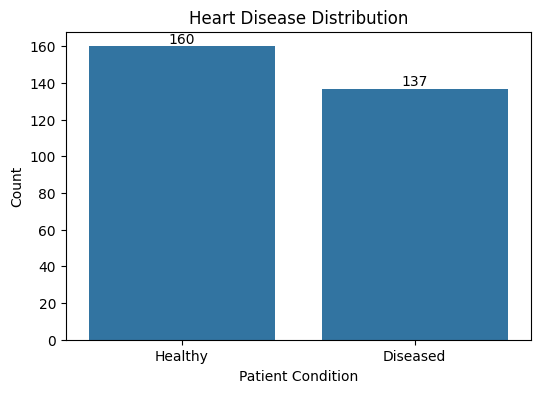

In [12]:
#Visualization of healthy and diseased patient distribution within the dataset.
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=df['Heart_Disease'].map({
        0: 'Healthy',
        1: 'Diseased'
    })
)

# Show counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Heart Disease Distribution")

plt.xlabel("Patient Condition")
plt.ylabel("Count")

plt.show()

### Insight of heart disease distribution
The dataset contains 160 healthy patients and 137 diseased patients, indicating a reasonably balanced class distribution between the two groups. This balanced distribution is beneficial for machine learning tasks because it helps reduce prediction bias toward a single class. Additionally, the presence of both healthy and diseased patient records supports meaningful comparative analysis of cardiovascular biomarkers and heart disease risk factors.

## Age Distribution

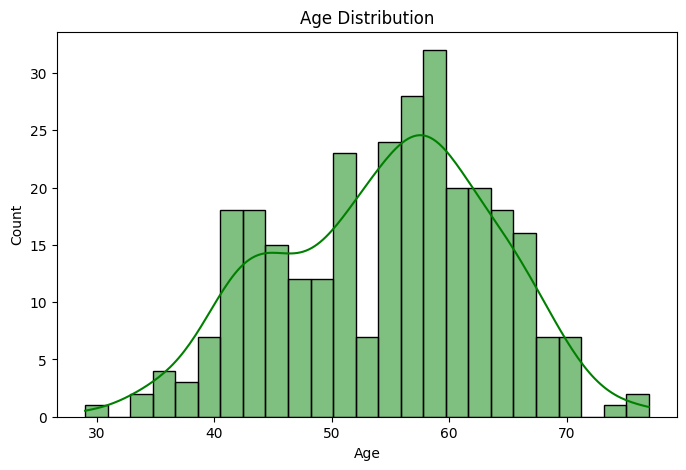

In [13]:
# Visualization of Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],
             bins=25,
             kde=True,
             color='green')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution Insights
The age distribution shows that the highest concentration of patients is observed between 50 and 60 years of age, with the peak occurring near age 60. Patient frequency is comparatively lower in other age groups, indicating that middle-aged and older adults represent the dominant population in the dataset.
This trend suggests that increasing age may be strongly associated with higher cardiovascular disease risk.

## Gender Distribution

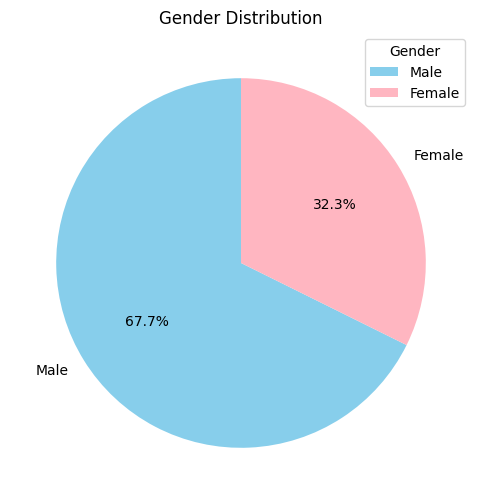

In [14]:
# pie chart for Gender distribution
df['Gender'] = df['Gender'].replace({
    0: 'Female',
    1: 'Male'
})
# Count gender values
gender_counts = df['Gender'].value_counts()
# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    pctdistance=0.6,   # moves percentage toward center
    startangle=90,
    colors=['skyblue', 'lightpink']
)
# Add legend
plt.legend(
    title="Gender",
    loc="upper right"
)

plt.title("Gender Distribution")

plt.show()

### Insights of gender distribution

Male patients represent 67.7% of the dataset, while female patients account for 32.3%. This indicates a higher representation of males in the heart disease dataset, suggesting that gender may play an important role in cardiovascular risk analysis.

## Cholesterol Distribution

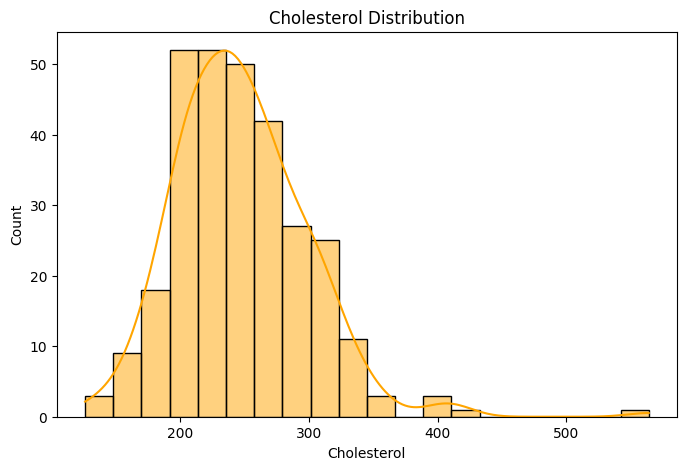

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Cholesterol'],
             bins=20,
             kde=True,
             color='orange')

plt.title("Cholesterol Distribution")

plt.xlabel("Cholesterol")
plt.ylabel("Count")

plt.show()

### Insights of Cholesterol Distribution
Most people in this dataset have borderline or high cholesterol (200–320 mg/dL), indicating a generally high-risk population for cardiovascular disease. A small number of extreme outliers suggest severe conditions like Hypercholesterolemia.
Overall, it points to weak preventive care and strong demand for screening and lifestyle intervention programs.

## Blood Pressure Distribution

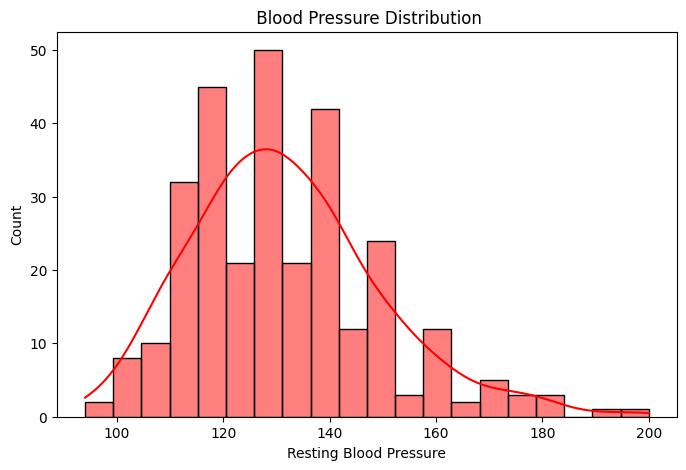

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Resting_Blood_Pressure'],
             bins=20,
             kde=True,
             color='red')

plt.title(" Blood Pressure Distribution")

plt.xlabel("Resting Blood Pressure")
plt.ylabel("Count")

plt.show()

### Insights of Blood Pressure Distribution
Most individuals fall in the elevated (120–129 mm Hg) and hypertensive (130–150 mm Hg) ranges, with only a small portion in the normal range. The right-skewed shape and tail up to 200 mm Hg show a significant high-risk subgroup with severe hypertension.
Overall, it indicates a generally high cardiovascular risk population needing intervention and monitoring.

## Max Heart Rate Distribution

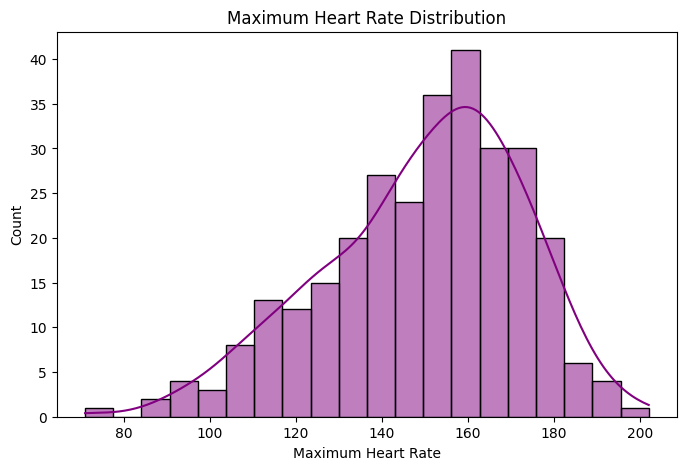

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Max_Heart_Rate'],
             bins=20,
             kde=True,
             color='purple')

plt.title("Maximum Heart Rate Distribution")

plt.xlabel("Maximum Heart Rate")
plt.ylabel("Count")

plt.show()

### Insights of Heart Rate Distribution
Most people have high max heart rates (135–175 bpm), peaking around 155–160 bpm, showing generally normal cardiovascular fitness. The left-skewed tail represents a small group with lower heart rate response due to age or medication.
Overall, the population is mostly healthy with a few low outliers.

# Bivariate Analysis

## Age vs Heart Disease

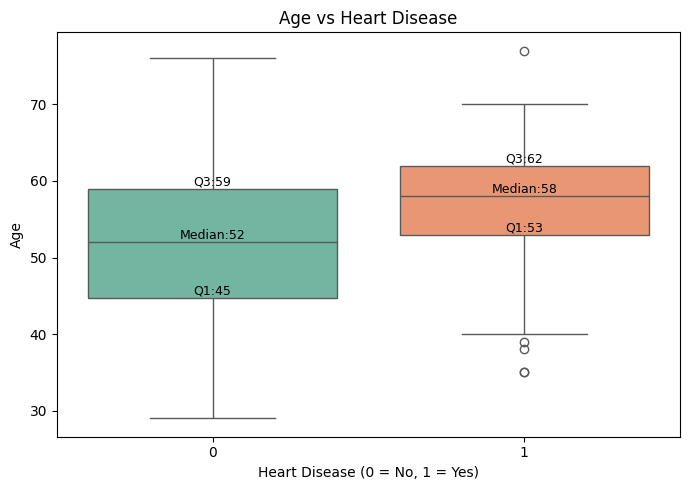

In [41]:
plt.figure(figsize=(7,5))

ax = sns.boxplot(
    x='Heart_Disease',
    y='Age',
    data=df,
    hue='Heart_Disease',   # FIX for seaborn warning
    palette='Set2',
    legend=False           # removes duplicate legend
)

# calculate Q1, Median, Q3
q1 = df.groupby('Heart_Disease')['Age'].quantile(0.25)
median = df.groupby('Heart_Disease')['Age'].median()
q3 = df.groupby('Heart_Disease')['Age'].quantile(0.75)

# add text on plot
for i in q1.index:
    plt.text(i, q1[i], f"Q1:{q1[i]:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, median[i], f"Median:{median[i]:.0f}", ha='center', va='bottom', fontsize=9)
    plt.text(i, q3[i], f"Q3:{q3[i]:.0f}", ha='center', va='bottom', fontsize=9)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### Insights of Age vs Heart Disease
Individuals with heart disease are generally older, showing a higher median age than those without. Most cases cluster between 50–62 years, indicating a strong age-related risk. A few younger outliers suggest heart disease can still occur early due to other factors.

# Advanced Exploratory Data Analysis (EDA)

### Correlation Heatmap

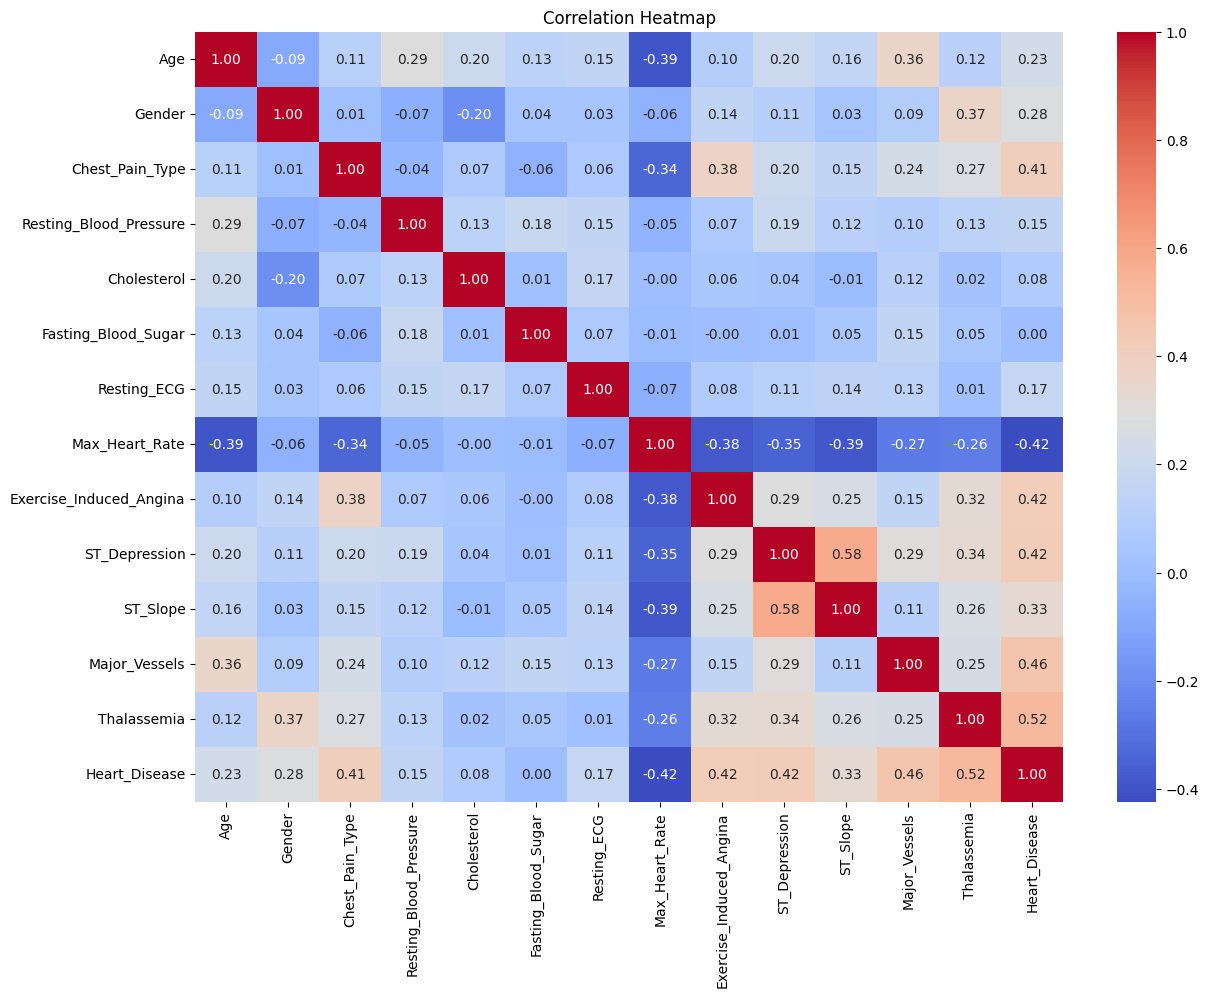

In [38]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap was used to identify relationships between medical features and heart disease. Strong positive and negative correlations help determine which biomarkers have the greatest influence on disease prediction. This analysis also helps detect multicollinearity among features.

### Chest Pain Type vs Heart Disease

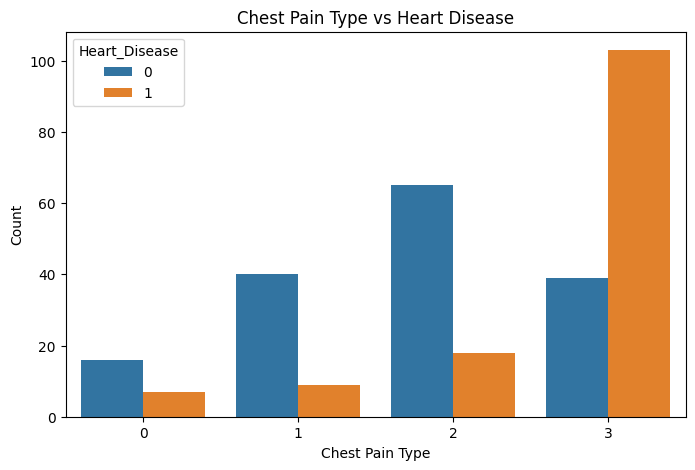

In [42]:
# Chest Pain Type vs Heart Disease

plt.figure(figsize=(8,5))
sns.countplot(
    x='Chest_Pain_Type',
    hue='Heart_Disease',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

This graph shows the relationship between different chest pain types and the presence of heart disease. Certain chest pain categories appear more frequently among patients diagnosed with heart disease, indicating that chest pain type is an important clinical indicator for disease prediction.

### Exercise-Induced Angina vs Heart Disease

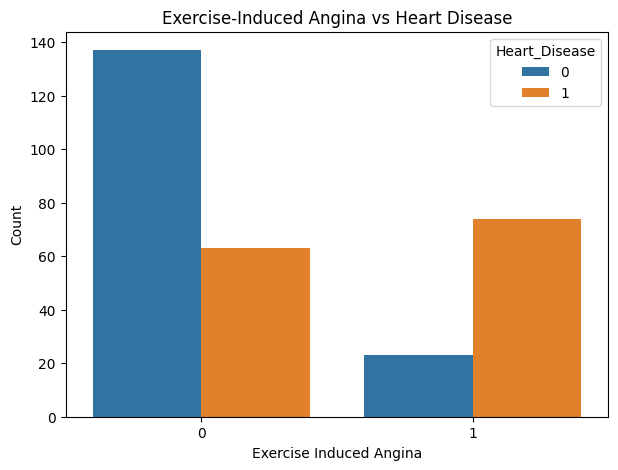

In [43]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Exercise_Induced_Angina',
    hue='Heart_Disease',
    data=df
)

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise Induced Angina")
plt.ylabel("Count")
plt.show()

This graph analyzes whether exercise-induced chest pain is associated with heart disease. Patients experiencing exercise-induced angina tend to show a higher likelihood of being diagnosed with heart disease.

### Fasting Blood Sugar vs Heart Disease

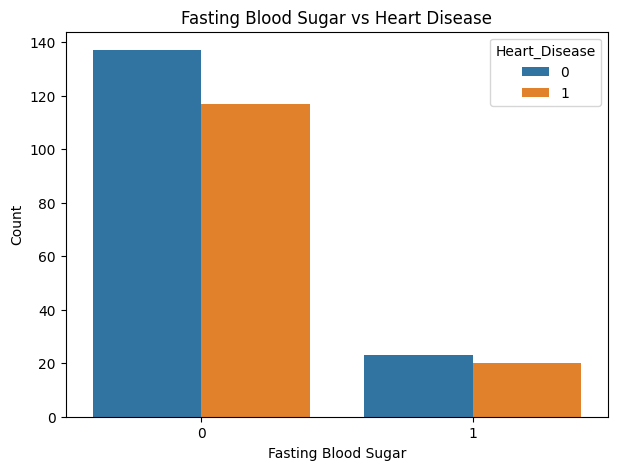

In [44]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Fasting_Blood_Sugar',
    hue='Heart_Disease',
    data=df
)

plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Count")
plt.show()

This graph compares fasting blood sugar levels with heart disease occurrence. Elevated fasting blood sugar levels may contribute to cardiovascular complications and increased disease risk.

### Resting ECG vs Heart Disease

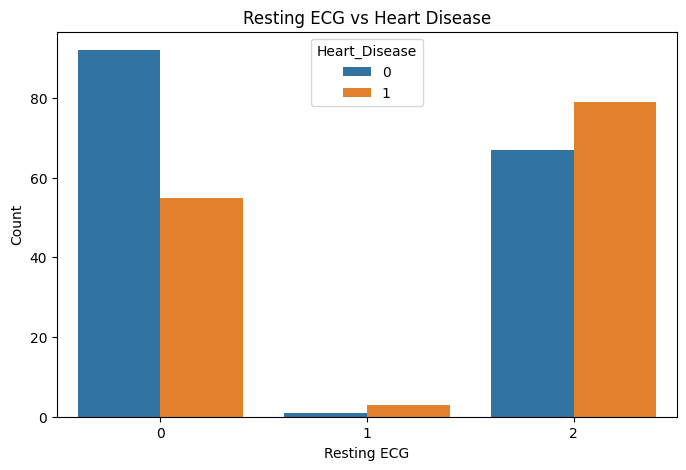

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Resting_ECG',
    hue='Heart_Disease',
    data=df
)

plt.title("Resting ECG vs Heart Disease")
plt.xlabel("Resting ECG")
plt.ylabel("Count")
plt.show()

This visualization shows how different resting ECG results relate to heart disease diagnosis. Abnormal ECG patterns appear more frequently among patients diagnosed with heart disease.

### Pairplot

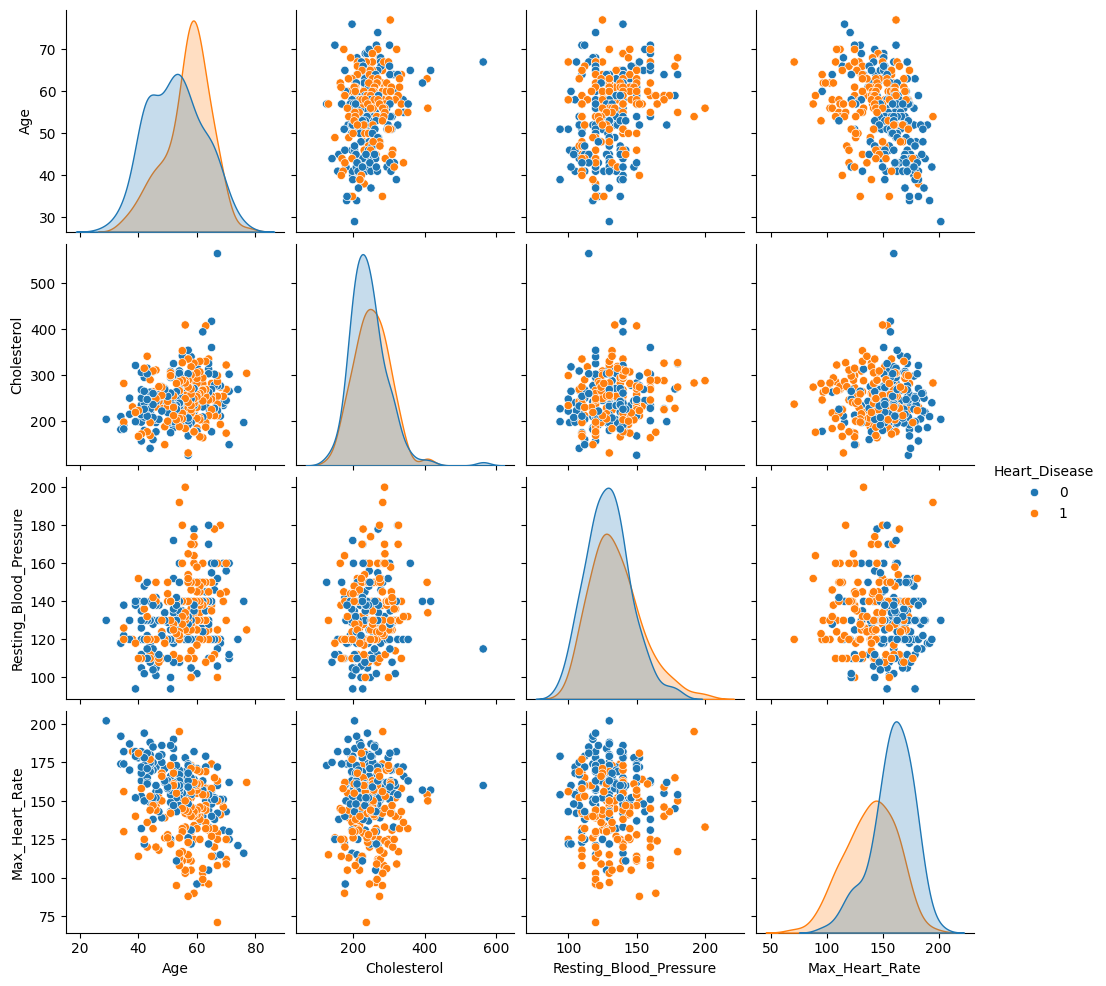

In [46]:
sns.pairplot(
    df[
        [
            'Age',
            'Cholesterol',
            'Resting_Blood_Pressure',
            'Max_Heart_Rate',
            'Heart_Disease'
        ]
    ],
    hue='Heart_Disease'
)

plt.show()

The pairplot visualizes relationships between important numerical healthcare variables. It helps identify trends, clusters, and correlations among biomarkers associated with heart disease.

# Week 3: Predictive Modeling and Algorithm

The objective of this phase was to build and evaluate machine learning models for heart disease prediction. We trained classification algorithms like Logistic Regression and Random Forest, handled class imbalance using SMOTE, and evaluated the models using metrics such as Accuracy, Recall, and ROC-AUC to identify the best-performing healthcare prediction model.




In [19]:
# Importing required libraries
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Handling class imbalance
from imblearn.over_sampling import SMOTE

In [20]:
df = pd.read_csv("cleaned_heart_disease_dataset.csv")
df.head()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Major_Vessels,Thalassemia,Heart_Disease
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


### Define Features and Target Variable

In [33]:
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (297, 13)
Target Shape: (297,)


The dataset was divided into independent features (X) and the target variable (y). The target variable represents whether a patient is diagnosed with heart disease, while the remaining columns are used as predictive biomarkers.

### Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (237, 13)
Testing Set Shape: (60, 13)


The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to train machine learning models, while the testing set is used to evaluate model performance on unseen data. Stratified splitting was applied to preserve class distribution across both datasets.

### Handling Class Imbalance using SMOTE

In [34]:
# Checking class distribution

print(y_train.value_counts())

# Applying SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# New class distribution
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Heart_Disease
0    128
1    109
Name: count, dtype: int64

After SMOTE:
Heart_Disease
1    128
0    128
Name: count, dtype: int64


Class imbalance can negatively affect machine learning performance, especially in healthcare datasets where diseased patients may be fewer than healthy patients. To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to generate synthetic minority class samples and balance the dataset.

### Logistic Regression Model

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model
lr_model = LogisticRegression(max_iter=5000)

# Train model
lr_model.fit(X_train_scaled, y_train_smote)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8833333333333333


A Logistic Regression model was implemented as the baseline classification algorithm. Logistic Regression is widely used in healthcare analytics because it is simple, interpretable, and effective for binary classification problems such as disease prediction.

### Logistic Regression Evaluation

              precision    recall  f1-score   support

           0       0.84      0.97      0.90        32
           1       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



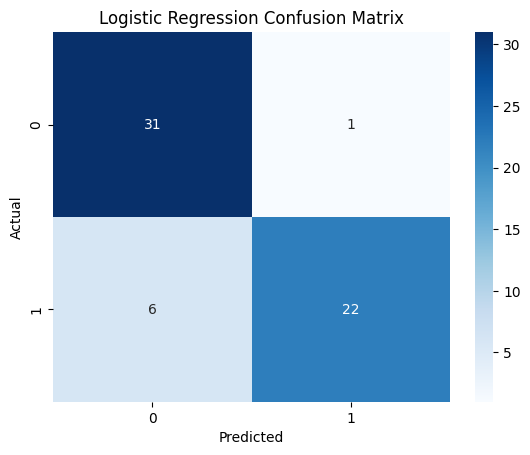

In [35]:
# Classification report
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The Logistic Regression model was evaluated using classification metrics such as Precision, Recall, F1-score, and Accuracy. A confusion matrix was also generated to visualize the number of correctly and incorrectly classified patient cases.

### Random Forest Classifier

In [36]:
# Building Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training the model
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8833333333333333


Random Forest was implemented as an ensemble machine learning algorithm to improve prediction performance. The algorithm combines multiple decision trees to enhance classification accuracy and reduce overfitting.

### Random Forest Evaluation

              precision    recall  f1-score   support

           0       0.84      0.97      0.90        32
           1       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



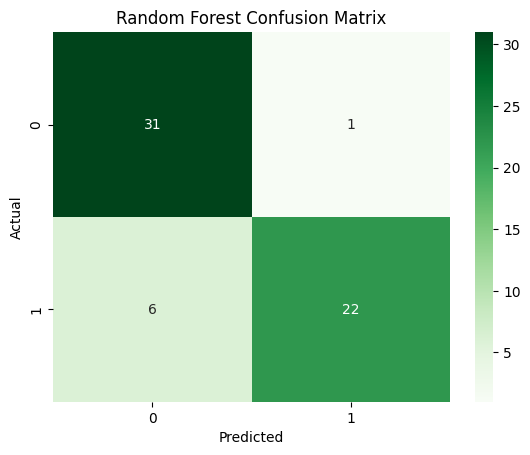

In [37]:
# Classification Report
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The Random Forest model was evaluated using multiple classification metrics. The confusion matrix demonstrates the model’s capability to correctly identify both diseased and non-diseased patients.

### Hyperparameter Tuning

In [29]:
# Hyperparameter tuning for Random Forest

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='recall'
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


Hyperparameter tuning was performed using GridSearchCV to optimize the Random Forest model’s performance. The tuning process tested multiple parameter combinations to identify the configuration that achieved the highest Recall score.